# Анализ графов Entity Resolution

Визуализация и анализ HeteroData-графов, построенных скриптом `02_build_graphs.py`.

Граф — двудольный (row ↔ token):
- **row**: строки обеих таблиц (A + B)
- **token**: уникальные субтокены ruBERT
- **edge_col_idx**: индекс столбца для каждого ребра (указывает на `col_embeddings`)
- **col_embeddings**: матрица эмбеддингов столбцов `[n_cols, 4096]`

Загружаем из `data/graphs/<name>/`.

In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (12, 5)

GRAPHS_DIR = Path("../data/graphs")

# Загрузка сводки
summary_path = GRAPHS_DIR / "graph_summary.json"
if summary_path.exists():
    with open(summary_path) as f:
        summary = json.load(f)
    print(f"Всего датасетов: {summary['total']}, failed: {summary['failed']}")
else:
    print("graph_summary.json не найден — сначала запустите 02_build_graphs.py --all")
    summary = None

Всего датасетов: 24, failed: []


## 1. Сводная статистика по всем графам

In [2]:
# Собрать stats.json из каждого датасета
all_stats = []
for ds_dir in sorted(GRAPHS_DIR.iterdir()):
    stats_file = ds_dir / "stats.json"
    if ds_dir.is_dir() and ds_dir.name != "unified" and stats_file.exists():
        with open(stats_file) as f:
            all_stats.append(json.load(f))

df_stats = pd.DataFrame(all_stats)
cols = ["name", "domain", "n_rows", "n_rows_a", "n_rows_b",
        "n_tokens", "n_edges", "n_train_triplets", "n_val_triplets",
        "n_train_positives", "n_train_negatives"]
display(df_stats[cols].style
    .set_caption("Статистика per-dataset графов")
    .background_gradient(subset=["n_rows", "n_tokens", "n_edges"], cmap="YlOrRd")
    .format(thousands=",")
)

# Итого
print(f"\nВсего строк (row): {df_stats['n_rows'].sum():,}")
print(f"Всего токенов (token): {df_stats['n_tokens'].sum():,}")
print(f"Всего рёбер: {df_stats['n_edges'].sum():,}")
print(f"Всего train triplets: {df_stats['n_train_triplets'].sum():,}")
print(f"Всего val triplets: {df_stats['n_val_triplets'].sum():,}")

,name,domain,n_rows,n_rows_a,n_rows_b,n_tokens,n_edges,n_train_triplets,n_val_triplets,n_train_positives,n_train_negatives
0,anime,anime,"8,000","4,000","4,000","5,086","186,953",425,96,88,149
1,baby_products,baby products,"15,803","5,085","10,718","6,973","543,189",220,36,70,170
2,beer,beer,"7,345","4,345","3,000","5,633","86,501",170,57,36,234
3,bikes,bikes,"13,789","4,786","9,003","2,568","259,735",330,96,73,197
4,books1,books,"7,014","3,506","3,508","9,304","204,278",660,120,142,84
5,books2,books,"7,668","3,967","3,701","14,432","320,021",280,51,57,182
6,books3,books,"6,121","3,022","3,099","6,857","182,340",945,186,194,76
7,books4,books,"18,597","8,639","9,958","12,417","699,580",300,48,62,208
8,books5,books,"5,997","2,999","2,998","8,159","180,092",120,18,25,215
9,citations,bibliography,"7,003","3,122","3,881","12,182","282,830",230,63,50,190



Всего строк (row): 365,316
Всего токенов (token): 247,530
Всего рёбер: 12,739,713
Всего train triplets: 7,550
Всего val triplets: 1,500


## 2. Распределение размеров графов по датасетам

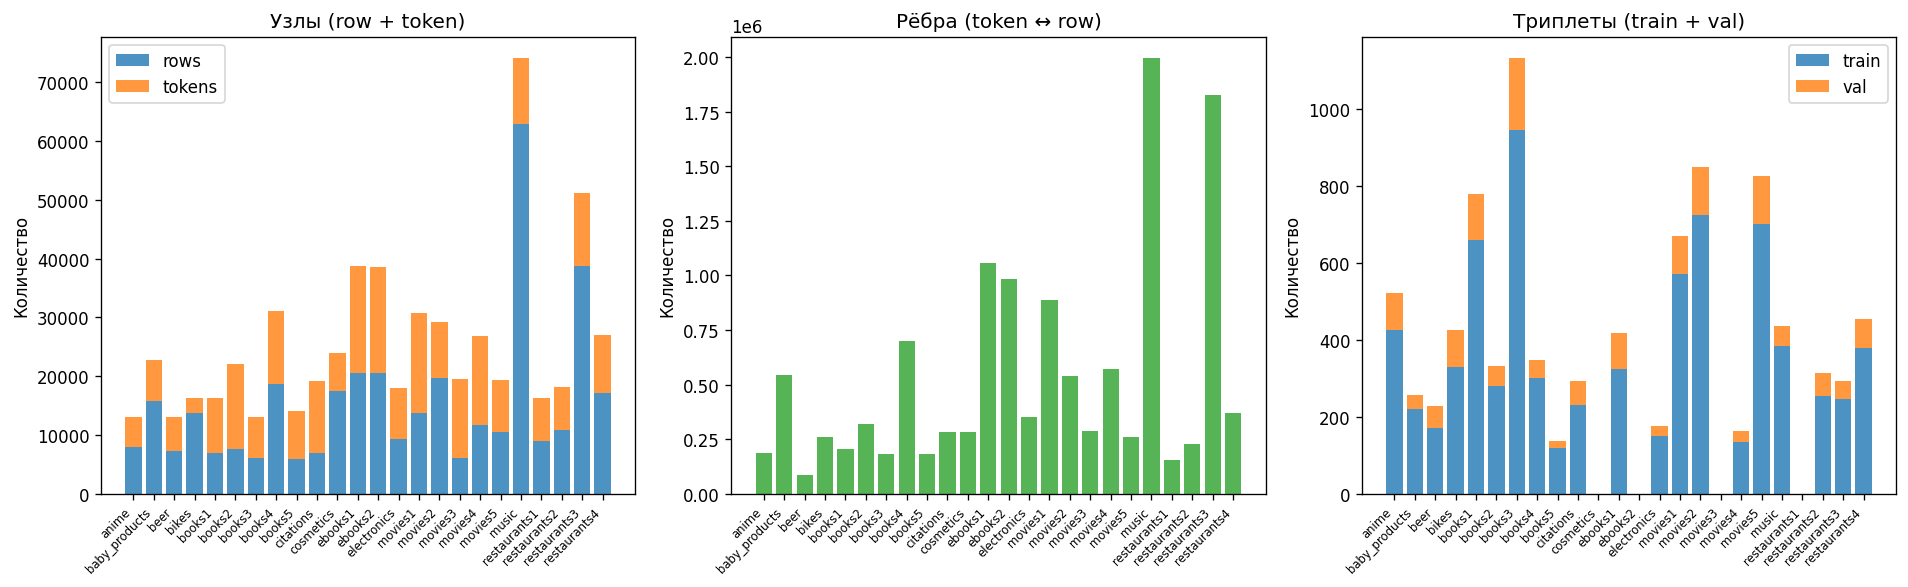

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names = df_stats["name"]
x = range(len(names))

# Узлы
axes[0].bar(x, df_stats["n_rows"], label="rows", alpha=0.8)
axes[0].bar(x, df_stats["n_tokens"], bottom=df_stats["n_rows"], label="tokens", alpha=0.8)
axes[0].set_title("Узлы (row + token)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha="right", fontsize=7)
axes[0].legend()
axes[0].set_ylabel("Количество")

# Рёбра
axes[1].bar(x, df_stats["n_edges"], color="C2", alpha=0.8)
axes[1].set_title("Рёбра (token ↔ row)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=45, ha="right", fontsize=7)
axes[1].set_ylabel("Количество")

# Триплеты
axes[2].bar(x, df_stats["n_train_triplets"], label="train", alpha=0.8)
axes[2].bar(x, df_stats["n_val_triplets"], bottom=df_stats["n_train_triplets"],
            label="val", alpha=0.8)
axes[2].set_title("Триплеты (train + val)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(names, rotation=45, ha="right", fontsize=7)
axes[2].legend()
axes[2].set_ylabel("Количество")

plt.tight_layout()
plt.show()

## 3. Загрузка и инспекция одного графа

In [4]:
# Выбрать датасет для детального анализа
DATASET_NAME = df_stats.iloc[0]["name"]  # можно заменить на любой
print(f"Детальный анализ: {DATASET_NAME}\n")

graph = torch.load(GRAPHS_DIR / DATASET_NAME / "graph.pt", weights_only=False)
train_tri = torch.load(GRAPHS_DIR / DATASET_NAME / "train_triplets.pt", weights_only=False)
val_tri = torch.load(GRAPHS_DIR / DATASET_NAME / "val_triplets.pt", weights_only=False)

print(f"row.x:            {graph['row'].x.shape}")
print(f"token.x:          {graph['token'].x.shape}")
print(f"edge (token→row): {graph['token', 'in_row', 'row'].edge_index.shape}")
print(f"edge_col_idx:     {graph['token', 'in_row', 'row'].edge_col_idx.shape}")
print(f"col_embeddings:   {graph.col_embeddings.shape}")
print(f"train triplets:   {train_tri.shape}")
print(f"val triplets:     {val_tri.shape}")

Детальный анализ: anime



c:\Users\olegk\Desktop\ДИПЛОМ\СуперДиплом\TableUnifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


row.x:            torch.Size([8000, 312])
token.x:          torch.Size([5086, 312])
edge (token→row): torch.Size([2, 186953])
edge_col_idx:     torch.Size([186953])
col_embeddings:   torch.Size([13, 4096])
train triplets:   torch.Size([425, 3])
val triplets:     torch.Size([96, 3])


## 4. Распределение степеней вершин (degree distribution)

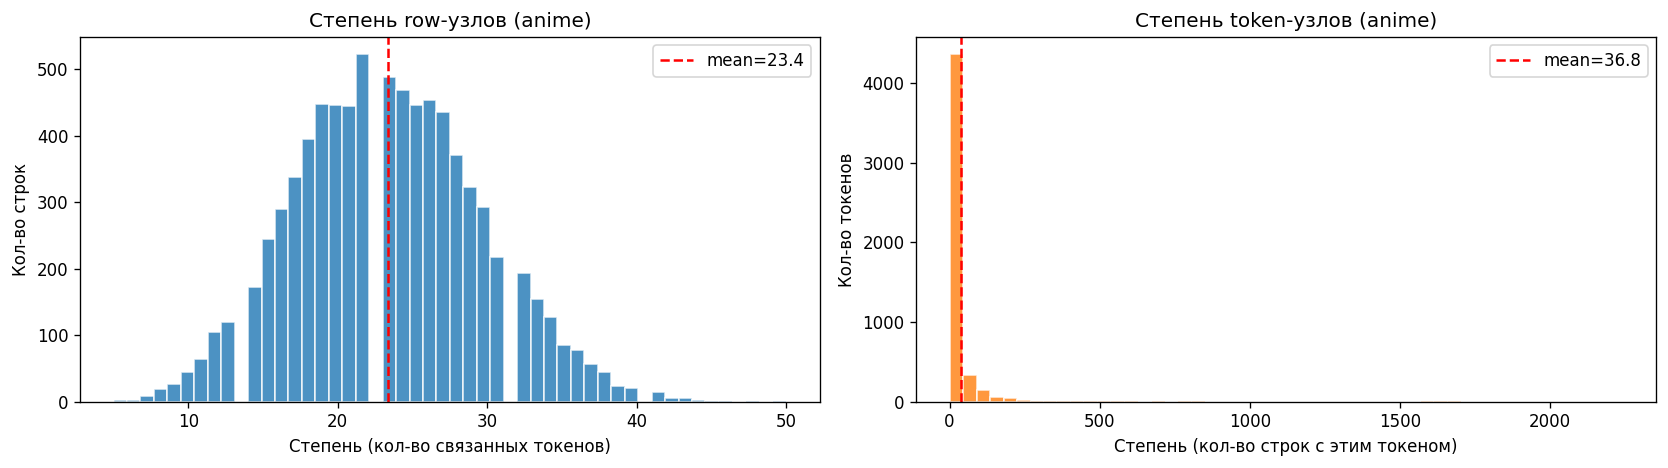

Row degree: min=5, max=50, mean=23.4, median=23
Token degree: min=1, max=2241, mean=36.8, median=5


In [5]:
ei = graph["token", "in_row", "row"].edge_index  # [2, E]

# Степень row-узлов (сколько токенов связано с каждой строкой)
row_deg = torch.zeros(graph["row"].x.shape[0], dtype=torch.long)
row_deg.scatter_add_(0, ei[1], torch.ones(ei.shape[1], dtype=torch.long))

# Степень token-узлов (в скольких строках встречается токен)
tok_deg = torch.zeros(graph["token"].x.shape[0], dtype=torch.long)
tok_deg.scatter_add_(0, ei[0], torch.ones(ei.shape[1], dtype=torch.long))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(row_deg.numpy(), bins=50, color="C0", alpha=0.8, edgecolor="white")
axes[0].set_title(f"Степень row-узлов ({DATASET_NAME})")
axes[0].set_xlabel("Степень (кол-во связанных токенов)")
axes[0].set_ylabel("Кол-во строк")
axes[0].axvline(row_deg.float().mean(), color="red", ls="--", label=f"mean={row_deg.float().mean():.1f}")
axes[0].legend()

axes[1].hist(tok_deg.numpy(), bins=50, color="C1", alpha=0.8, edgecolor="white")
axes[1].set_title(f"Степень token-узлов ({DATASET_NAME})")
axes[1].set_xlabel("Степень (кол-во строк с этим токеном)")
axes[1].set_ylabel("Кол-во токенов")
axes[1].axvline(tok_deg.float().mean(), color="red", ls="--", label=f"mean={tok_deg.float().mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Row degree: min={row_deg.min()}, max={row_deg.max()}, "
      f"mean={row_deg.float().mean():.1f}, median={row_deg.float().median():.0f}")
print(f"Token degree: min={tok_deg.min()}, max={tok_deg.max()}, "
      f"mean={tok_deg.float().mean():.1f}, median={tok_deg.float().median():.0f}")

## 5. Log-log график степени token-узлов

Проверка scale-free свойства: если линейно в log-log — степенной закон.

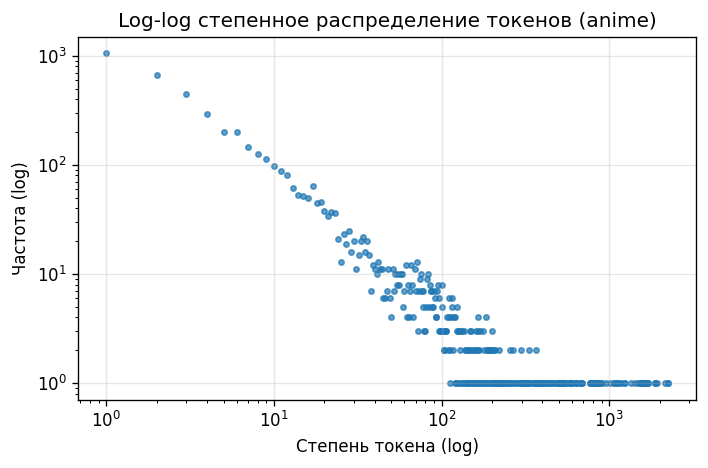

In [6]:
deg_counts = Counter(tok_deg.numpy().tolist())
degs = sorted(deg_counts.keys())
freqs = [deg_counts[d] for d in degs]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(degs, freqs, s=10, alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Степень токена (log)")
ax.set_ylabel("Частота (log)")
ax.set_title(f"Log-log степенное распределение токенов ({DATASET_NAME})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Соотношение row/token по датасетам и плотность графа

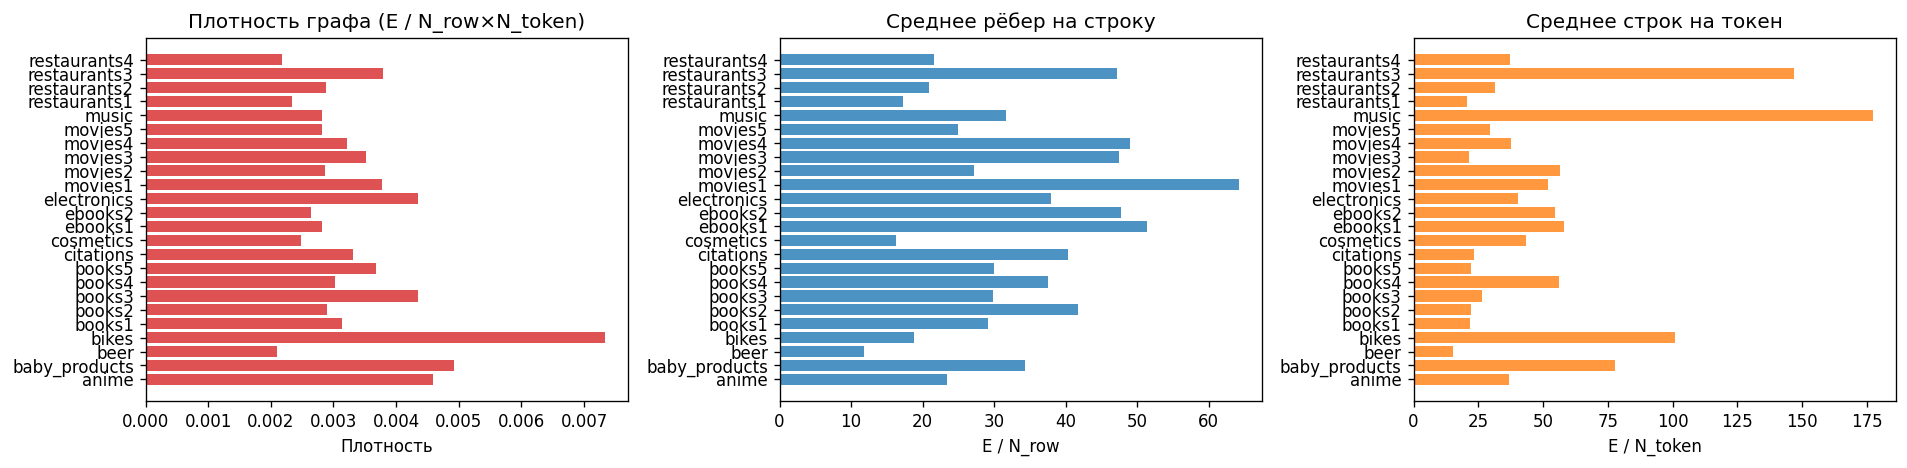

In [7]:
# Плотность двудольного графа: E / (N_row * N_token)
df_stats["density"] = df_stats["n_edges"] / (df_stats["n_rows"] * df_stats["n_tokens"])
df_stats["token_per_row"] = df_stats["n_edges"] / df_stats["n_rows"]
df_stats["rows_per_token"] = df_stats["n_edges"] / df_stats["n_tokens"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].barh(df_stats["name"], df_stats["density"], color="C3", alpha=0.8)
axes[0].set_title("Плотность графа (E / N_row×N_token)")
axes[0].set_xlabel("Плотность")

axes[1].barh(df_stats["name"], df_stats["token_per_row"], color="C0", alpha=0.8)
axes[1].set_title("Среднее рёбер на строку")
axes[1].set_xlabel("E / N_row")

axes[2].barh(df_stats["name"], df_stats["rows_per_token"], color="C1", alpha=0.8)
axes[2].set_title("Среднее строк на токен")
axes[2].set_xlabel("E / N_token")

plt.tight_layout()
plt.show()

## 7. Анализ связности: общие токены между таблицами A и B

Ключевой вопрос: насколько таблицы A и B связаны через общие токены?
Чем больше общих токенов — тем лучше GNN может передавать информацию между строками.

In [8]:
with open(GRAPHS_DIR / DATASET_NAME / "id_to_global_a.json") as f:
    id_to_global_a = json.load(f)
with open(GRAPHS_DIR / DATASET_NAME / "id_to_global_b.json") as f:
    id_to_global_b = json.load(f)

rows_a = set(id_to_global_a.values())
rows_b = set(id_to_global_b.values())

# Токены, связанные с A и B
tok_src = ei[0].numpy()
row_dst = ei[1].numpy()

tokens_of_a = set(tok_src[np.isin(row_dst, list(rows_a))])
tokens_of_b = set(tok_src[np.isin(row_dst, list(rows_b))])
shared_tokens = tokens_of_a & tokens_of_b

n_tok = graph["token"].x.shape[0]
print(f"Токены только в A:  {len(tokens_of_a - tokens_of_b)} / {n_tok} ({100*len(tokens_of_a - tokens_of_b)/n_tok:.1f}%)")
print(f"Токены только в B:  {len(tokens_of_b - tokens_of_a)} / {n_tok} ({100*len(tokens_of_b - tokens_of_a)/n_tok:.1f}%)")
print(f"Общие токены (A∩B): {len(shared_tokens)} / {n_tok} ({100*len(shared_tokens)/n_tok:.1f}%)")
print(f"\n→ Через {len(shared_tokens)} общих токенов GNN связывает строки таблиц A и B")

Токены только в A:  967 / 5086 (19.0%)
Токены только в B:  863 / 5086 (17.0%)
Общие токены (A∩B): 3242 / 5086 (63.7%)

→ Через 3242 общих токенов GNN связывает строки таблиц A и B


## 8. t-SNE визуализация row-эмбеддингов (A vs B)

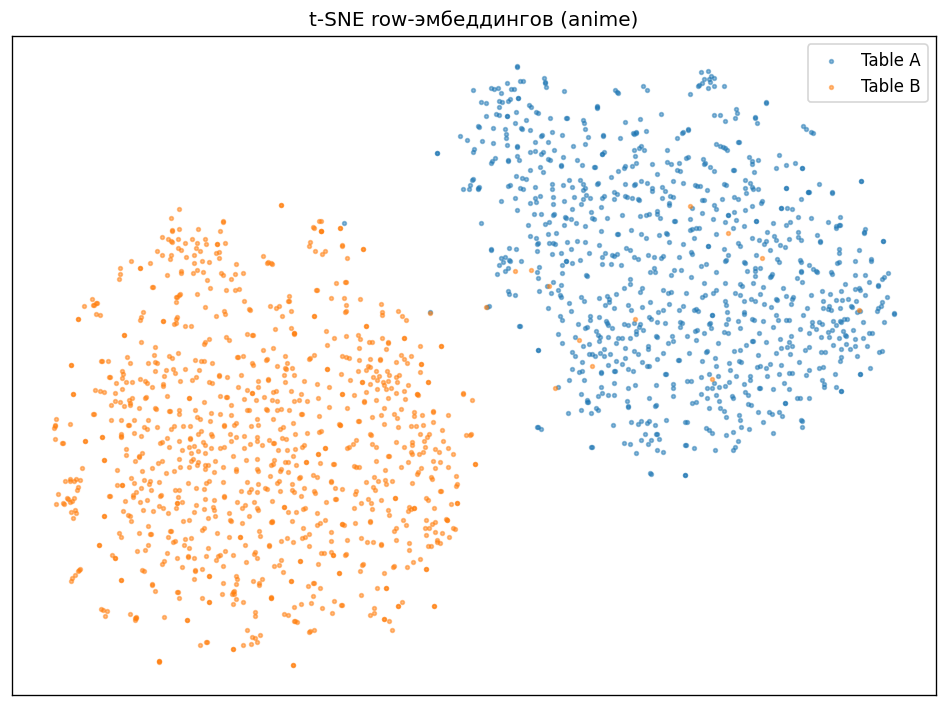

In [9]:
from sklearn.manifold import TSNE

row_x = graph["row"].x.numpy()
n_a = len(rows_a)

# Сэмплирование если слишком много строк
MAX_SAMPLE = 2000
if row_x.shape[0] > MAX_SAMPLE:
    idx = np.random.choice(row_x.shape[0], MAX_SAMPLE, replace=False)
    idx = np.sort(idx)
    row_x_sample = row_x[idx]
    labels = ["A" if i < n_a else "B" for i in idx]
else:
    row_x_sample = row_x
    labels = ["A"] * n_a + ["B"] * (row_x.shape[0] - n_a)

perplexity = min(30, len(row_x_sample) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
coords = tsne.fit_transform(row_x_sample)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [("A", "C0"), ("B", "C1")]:
    mask = [l == label for l in labels]
    ax.scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.5,
               label=f"Table {label}", color=color)
ax.set_title(f"t-SNE row-эмбеддингов ({DATASET_NAME})")
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 9. Сводная статистика по всем графам (агрегация)

СВОДКА ПО ВСЕМ ГРАФАМ
Датасетов:         24
Rows (total):      365,316
Tokens (total):    247,530
Edges (total):     12,739,713
Train triplets:    7,550
Val triplets:      1,500


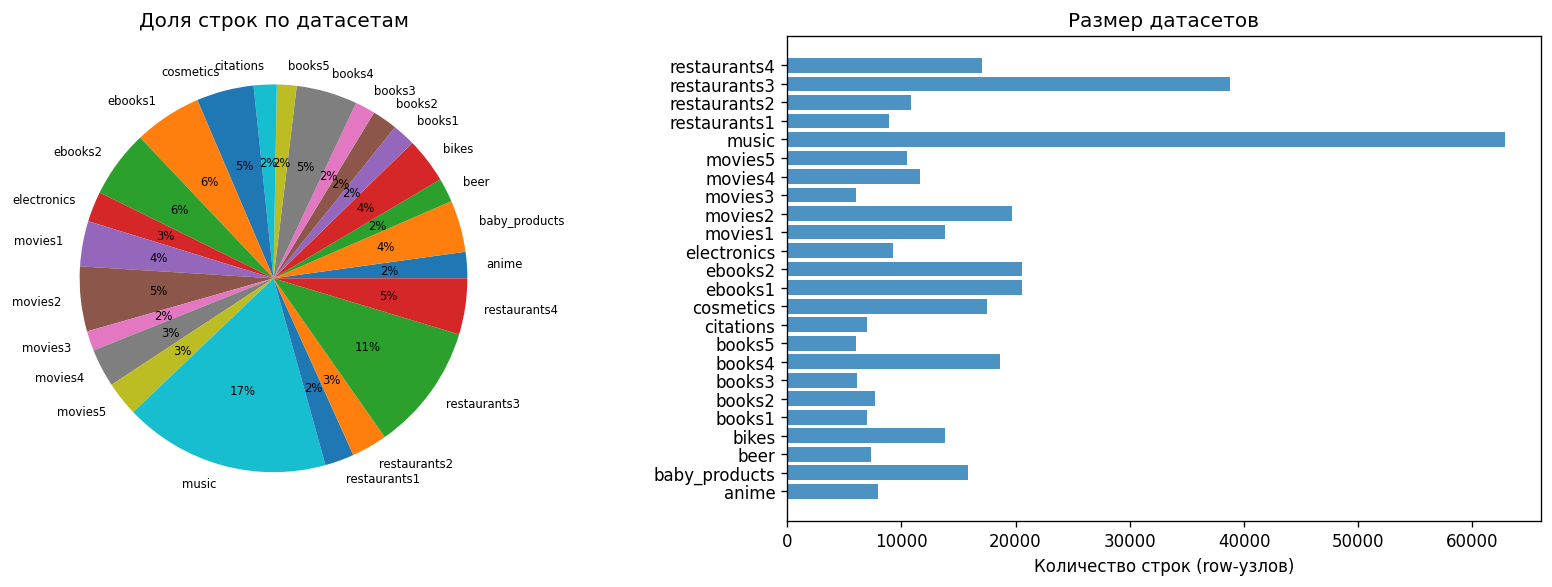

In [10]:
# Агрегированная статистика по всем per-dataset графам
print("=" * 50)
print("СВОДКА ПО ВСЕМ ГРАФАМ")
print("=" * 50)
print(f"Датасетов:         {len(df_stats)}")
print(f"Rows (total):      {df_stats['n_rows'].sum():,}")
print(f"Tokens (total):    {df_stats['n_tokens'].sum():,}")
print(f"Edges (total):     {df_stats['n_edges'].sum():,}")
print(f"Train triplets:    {df_stats['n_train_triplets'].sum():,}")
print(f"Val triplets:      {df_stats['n_val_triplets'].sum():,}")

# Pie chart: вклад каждого датасета в rows
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ds_names = df_stats["name"].tolist()
ds_rows = df_stats["n_rows"].tolist()
axes[0].pie(ds_rows, labels=ds_names, autopct="%1.0f%%", textprops={"fontsize": 7})
axes[0].set_title("Доля строк по датасетам")

# Bar: размер каждого датасета
axes[1].barh(ds_names, ds_rows, alpha=0.8)
axes[1].set_xlabel("Количество строк (row-узлов)")
axes[1].set_title("Размер датасетов")

plt.tight_layout()
plt.show()

## 10. Сравнение средней степени по доменам

In [11]:
domain_agg = df_stats.groupby("domain").agg({
    "n_rows": "mean",
    "n_tokens": "mean",
    "n_edges": "mean",
    "density": "mean",
    "token_per_row": "mean",
    "name": "count",
}).rename(columns={"name": "n_datasets"}).sort_values("n_edges", ascending=False)

display(domain_agg.style
    .set_caption("Средние метрики по доменам")
    .format({"n_rows": "{:.0f}", "n_tokens": "{:.0f}", "n_edges": "{:.0f}",
             "density": "{:.4f}", "token_per_row": "{:.1f}"})
    .background_gradient(cmap="Blues")
)

,n_rows,n_tokens,n_edges,density,token_per_row,n_datasets
domain,,,,,,
music,62830,11239,1993951,0.0028,31.7,1
ebooks,20599,18136,1020962,0.0027,49.6,2
restaurants,18887,9260,644738,0.0028,26.8,4
baby products,15803,6973,543189,0.0049,34.4,1
movies,12335,12814,508705,0.0032,42.6,5
electronics,9260,8737,351801,0.0043,38.0,1
books,9079,10234,317262,0.0034,33.7,5
cosmetics,17469,6558,284046,0.0025,16.3,1
bibliography,7003,12182,282830,0.0033,40.4,1


## 11. Дисбаланс классов по датасетам (pos/neg ratio)

Для обучения с Triplet Loss важно знать реальный дисбаланс: сколько matching-пар (label=1) против non-matching (label=0) в каждом датасете.

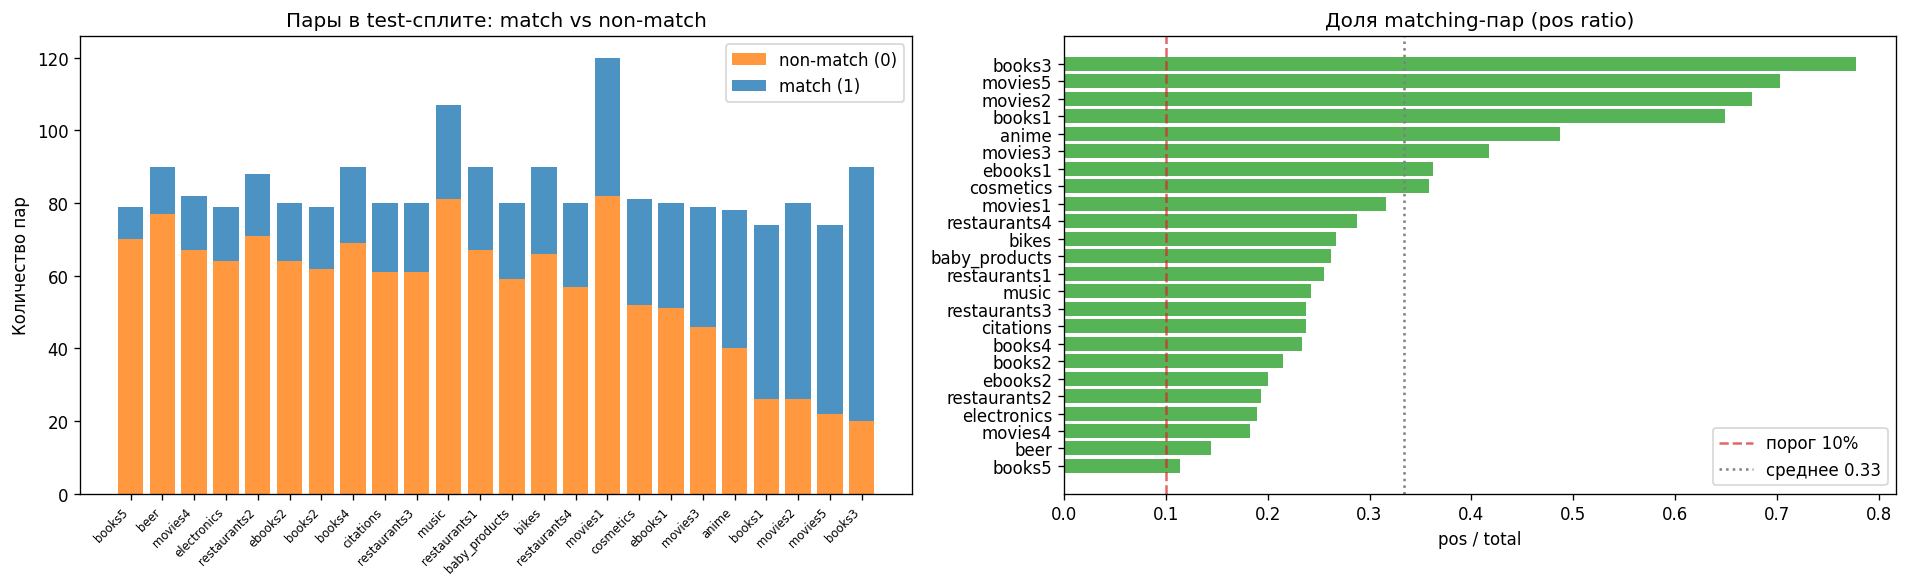

Среднее pos_ratio: 0.334
Мин / Макс: 0.114 / 0.778

Датасеты с pos_ratio < 10% (сильный дисбаланс):
Empty DataFrame
Columns: [dataset, domain, n_pos, n_neg, pos_ratio]
Index: []


In [12]:
class_rows = []
for ds in all_stats:
    name = ds["name"]
    test_path = GRAPHS_DIR / name / "test.csv"
    if not test_path.exists():
        continue
    test_df = pd.read_csv(test_path)
    if "label" not in test_df.columns:
        continue
    n_pos = (test_df["label"] == 1).sum()
    n_neg = (test_df["label"] == 0).sum()
    total = len(test_df)
    class_rows.append({
        "dataset": name,
        "domain": ds["domain"],
        "n_pos": n_pos,
        "n_neg": n_neg,
        "total": total,
        "pos_ratio": n_pos / total if total > 0 else 0,
    })

df_class = pd.DataFrame(class_rows).sort_values("pos_ratio")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar: pos vs neg
x = range(len(df_class))
axes[0].bar(x, df_class["n_neg"], label="non-match (0)", alpha=0.8, color="C1")
axes[0].bar(x, df_class["n_pos"], bottom=df_class["n_neg"], label="match (1)", alpha=0.8, color="C0")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_class["dataset"], rotation=45, ha="right", fontsize=7)
axes[0].set_title("Пары в test-сплите: match vs non-match")
axes[0].set_ylabel("Количество пар")
axes[0].legend()

# Pos ratio
colors = ["C3" if r < 0.1 else "C2" for r in df_class["pos_ratio"]]
axes[1].barh(df_class["dataset"], df_class["pos_ratio"], color=colors, alpha=0.8)
axes[1].axvline(0.1, color="C3", ls="--", alpha=0.7, label="порог 10%")
axes[1].axvline(df_class["pos_ratio"].mean(), color="gray", ls=":", label=f"среднее {df_class['pos_ratio'].mean():.2f}")
axes[1].set_title("Доля matching-пар (pos ratio)")
axes[1].set_xlabel("pos / total")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Среднее pos_ratio: {df_class['pos_ratio'].mean():.3f}")
print(f"Мин / Макс: {df_class['pos_ratio'].min():.3f} / {df_class['pos_ratio'].max():.3f}")
print(f"\nДатасеты с pos_ratio < 10% (сильный дисбаланс):")
print(df_class[df_class["pos_ratio"] < 0.1][["dataset", "domain", "n_pos", "n_neg", "pos_ratio"]].to_string(index=False))

## 12. IDF-распределение токенов — обоснование фильтрации

Для каждого токена вычисляем **document frequency** (df): в скольких строках он встречается.

- Токены с высоким df — стоп-слова, пунктуация, артикли → не различают сущности, создают балласт в графе
- Токены с низким df — имена, числа, коды → ключевые для entity resolution

Выбранный порог `max_token_df=0.3` (30% строк) обоснован этим анализом.

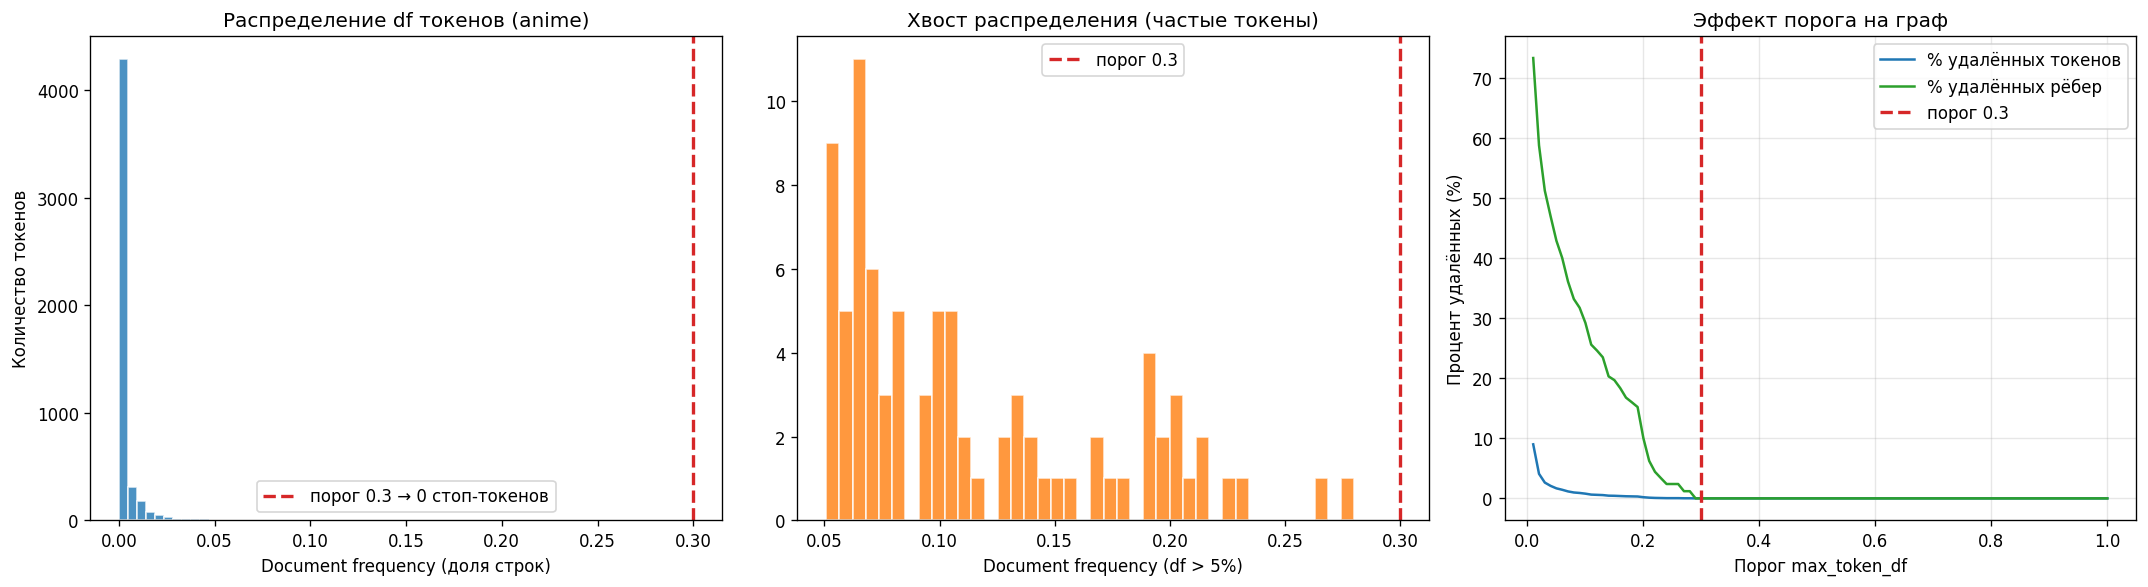

При пороге 0.3:
  Стоп-токенов: 0 / 5086 (0.0%)
  Удаляемых рёбер: 0.0%


In [13]:
# Вычисляем df для каждого токена в выбранном графе
ei = graph["token", "in_row", "row"].edge_index  # [2, E]
n_rows_graph = graph["row"].x.shape[0]
n_tokens_graph = graph["token"].x.shape[0]

# df[token] = количество уникальных строк, в которых встречается токен
from collections import defaultdict as _dd
tok_rows = _dd(set)
for t, r in zip(ei[0].numpy(), ei[1].numpy()):
    tok_rows[int(t)].add(int(r))

df_values = np.array([len(tok_rows[t]) for t in range(n_tokens_graph)])
df_ratio = df_values / n_rows_graph

MAX_DF_THRESHOLD = 0.3

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма df_ratio
axes[0].hist(df_ratio, bins=60, color="C0", alpha=0.8, edgecolor="white")
axes[0].axvline(MAX_DF_THRESHOLD, color="C3", ls="--", lw=2,
                label=f"порог {MAX_DF_THRESHOLD} → {(df_ratio > MAX_DF_THRESHOLD).sum()} стоп-токенов")
axes[0].set_xlabel("Document frequency (доля строк)")
axes[0].set_ylabel("Количество токенов")
axes[0].set_title(f"Распределение df токенов ({DATASET_NAME})")
axes[0].legend()

# Zoom: хвост (>0.1 df)
mask_tail = df_ratio > 0.05
axes[1].hist(df_ratio[mask_tail], bins=40, color="C1", alpha=0.8, edgecolor="white")
axes[1].axvline(MAX_DF_THRESHOLD, color="C3", ls="--", lw=2, label=f"порог {MAX_DF_THRESHOLD}")
axes[1].set_xlabel("Document frequency (df > 5%)")
axes[1].set_title("Хвост распределения (частые токены)")
axes[1].legend()

# Пороговая кривая: % удалённых токенов vs порог
thresholds = np.linspace(0.01, 1.0, 100)
pct_removed = [(df_ratio > t).mean() * 100 for t in thresholds]
pct_edges_removed = []
for t in thresholds:
    stopword_set = set(np.where(df_ratio > t)[0])
    removed = sum(1 for tok in ei[0].numpy() if tok in stopword_set)
    pct_edges_removed.append(removed / ei.shape[1] * 100)

axes[2].plot(thresholds, pct_removed, label="% удалённых токенов", color="C0")
axes[2].plot(thresholds, pct_edges_removed, label="% удалённых рёбер", color="C2")
axes[2].axvline(MAX_DF_THRESHOLD, color="C3", ls="--", lw=2, label=f"порог {MAX_DF_THRESHOLD}")
axes[2].set_xlabel("Порог max_token_df")
axes[2].set_ylabel("Процент удалённых (%)")
axes[2].set_title("Эффект порога на граф")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_stop = (df_ratio > MAX_DF_THRESHOLD).sum()
stop_edge_pct = sum(1 for t in ei[0].numpy() if df_ratio[t] > MAX_DF_THRESHOLD) / ei.shape[1] * 100
print(f"При пороге {MAX_DF_THRESHOLD}:")
print(f"  Стоп-токенов: {n_stop} / {n_tokens_graph} ({n_stop/n_tokens_graph*100:.1f}%)")
print(f"  Удаляемых рёбер: {stop_edge_pct:.1f}%")

## 13. Вклад столбцов в граф (edge_col_idx)

Какие столбцы порождают наибольшее число рёбер? Это показывает, какие столбцы наиболее «токенизированы» (длинные текстовые поля) и несут больше всего информации в GNN.

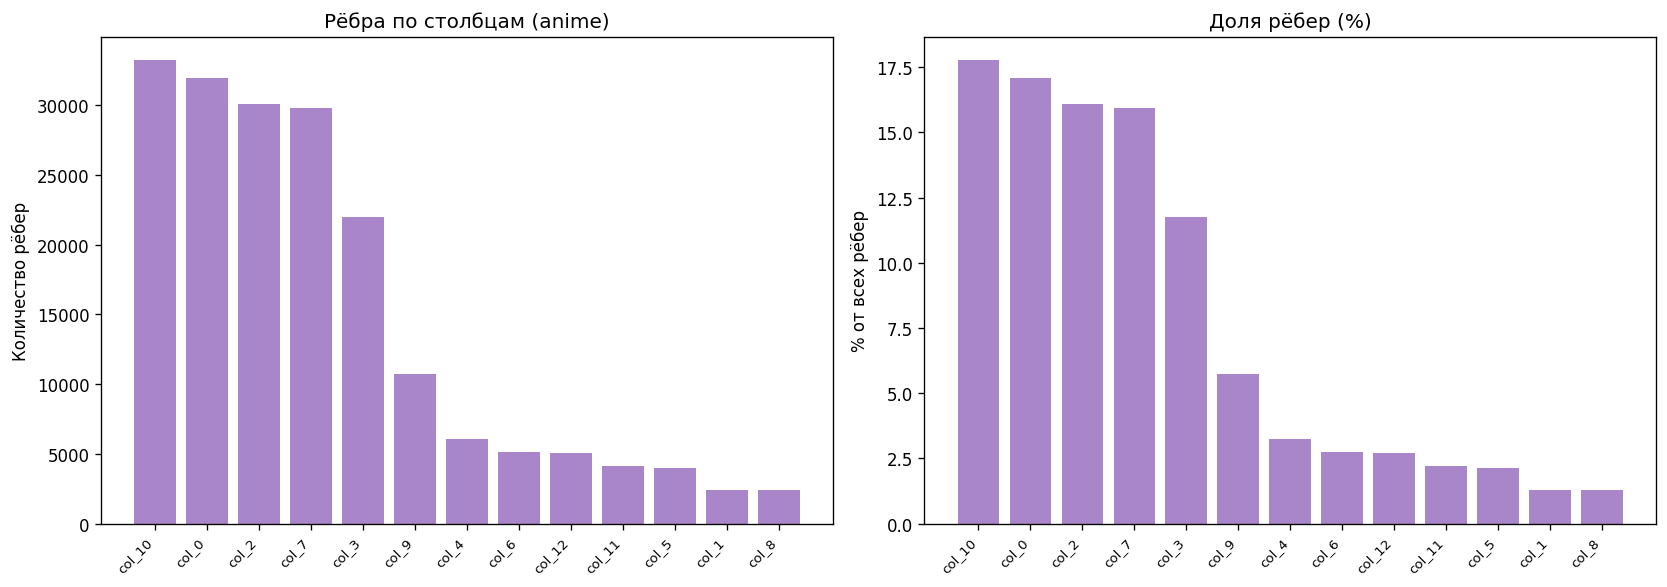

Топ-5 столбцов по числу рёбер:
  col_10: 33,244 рёбер (17.8%)
  col_0: 31,956 рёбер (17.1%)
  col_2: 30,107 рёбер (16.1%)
  col_7: 29,765 рёбер (15.9%)
  col_3: 21,984 рёбер (11.8%)

Gini неравномерности: 0.867 (0=равномерно, ~1=один столбец доминирует)


In [14]:
edge_col_idx = graph["token", "in_row", "row"].edge_col_idx.numpy()
n_cols = graph.col_embeddings.shape[0]

col_edge_counts = Counter(edge_col_idx.tolist())
col_ids = list(range(n_cols))
col_counts = [col_edge_counts.get(c, 0) for c in col_ids]
col_pcts = [c / len(edge_col_idx) * 100 for c in col_counts]

# Сортируем по убыванию
sorted_pairs = sorted(zip(col_ids, col_counts, col_pcts), key=lambda x: -x[1])
s_ids, s_counts, s_pcts = zip(*sorted_pairs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(n_cols), s_counts, color="C4", alpha=0.8)
axes[0].set_xticks(range(n_cols))
axes[0].set_xticklabels([f"col_{i}" for i in s_ids], rotation=45, ha="right", fontsize=8)
axes[0].set_title(f"Рёбра по столбцам ({DATASET_NAME})")
axes[0].set_ylabel("Количество рёбер")

axes[1].bar(range(n_cols), s_pcts, color="C4", alpha=0.8)
axes[1].set_xticks(range(n_cols))
axes[1].set_xticklabels([f"col_{i}" for i in s_ids], rotation=45, ha="right", fontsize=8)
axes[1].set_title("Доля рёбер (%)")
axes[1].set_ylabel("% от всех рёбер")

plt.tight_layout()
plt.show()

print("Топ-5 столбцов по числу рёбер:")
for cid, cnt, pct in sorted_pairs[:5]:
    print(f"  col_{cid}: {cnt:,} рёбер ({pct:.1f}%)")
print(f"\nGini неравномерности: {1 - sum((p/100)**2 for p in s_pcts):.3f} (0=равномерно, ~1=один столбец доминирует)")

## 14. Match vs non-match: перекрытие токенов

**Ключевое обоснование использования графа для ER:**  
Если matching-пары (label=1) разделяют значительно больше токенов, чем non-matching — граф кодирует релевантный сигнал для задачи.

Для каждой размеченной пары строк вычисляем **Jaccard similarity** по множеству токенов.

C:\Users\olegk\AppData\Local\Temp\ipykernel_21708\487079142.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


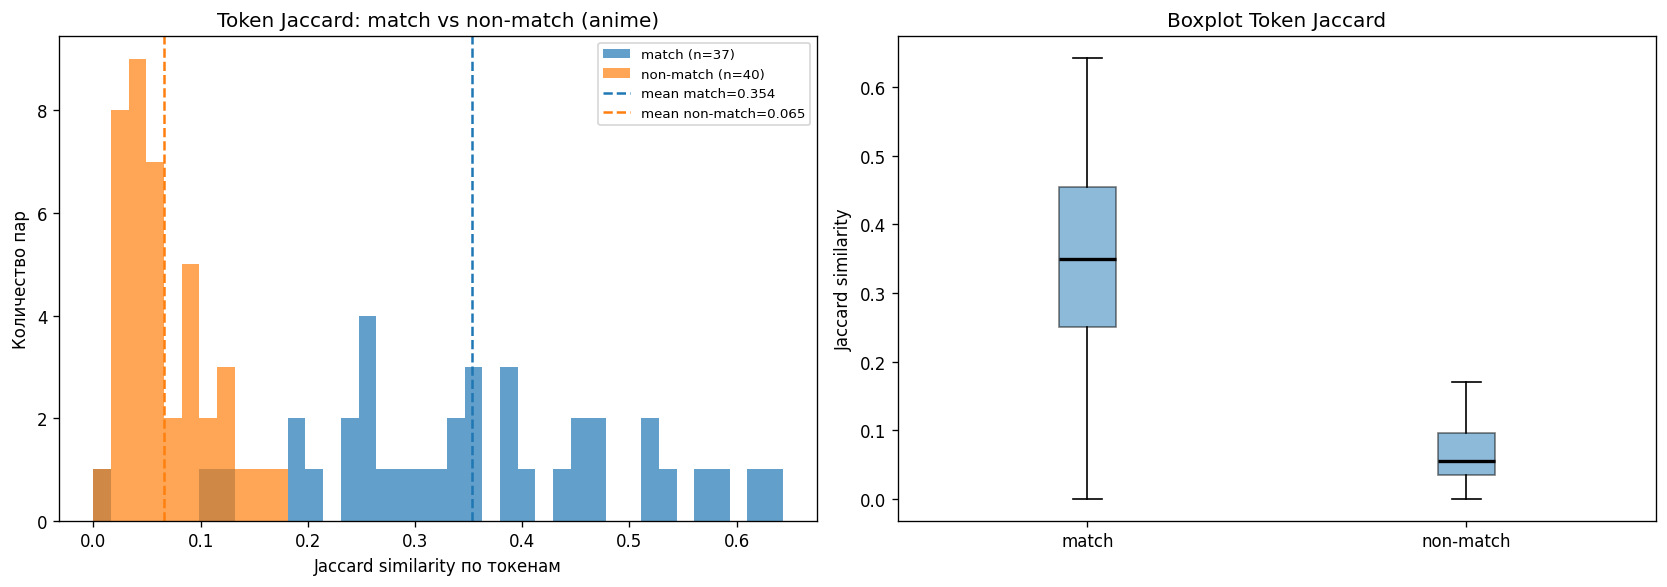

Mann-Whitney U test (match > non-match): p=1.1495e-12
→ Значимое различие — граф несёт релевантный сигнал для ER


In [15]:
test_path = GRAPHS_DIR / DATASET_NAME / "test.csv"
if not test_path.exists():
    print("test.csv не найден")
else:
    test_df = pd.read_csv(test_path)

    # Карта: row_idx → множество токенов
    row_tokens: dict[int, set] = _dd(set)
    for tok, row in zip(ei[0].numpy(), ei[1].numpy()):
        row_tokens[int(row)].add(int(tok))

    with open(GRAPHS_DIR / DATASET_NAME / "id_to_global_a.json") as f:
        id2g_a = {k: int(v) for k, v in json.load(f).items()}
    with open(GRAPHS_DIR / DATASET_NAME / "id_to_global_b.json") as f:
        id2g_b = {k: int(v) for k, v in json.load(f).items()}

    jaccards_match, jaccards_nonmatch = [], []
    overlaps_match, overlaps_nonmatch = [], []

    MAX_PAIRS = 1000  # ограничиваем для скорости
    for _, row in test_df.head(MAX_PAIRS).iterrows():
        lid = str(int(row["ltable_id"])) if not pd.isna(row["ltable_id"]) else None
        rid = str(int(row["rtable_id"])) if not pd.isna(row["rtable_id"]) else None
        label = int(row["label"])
        if lid not in id2g_a or rid not in id2g_b:
            continue
        toks_a = row_tokens[id2g_a[lid]]
        toks_b = row_tokens[id2g_b[rid]]
        union = toks_a | toks_b
        inter = toks_a & toks_b
        jacc = len(inter) / len(union) if union else 0.0
        if label == 1:
            jaccards_match.append(jacc)
            overlaps_match.append(len(inter))
        else:
            jaccards_nonmatch.append(jacc)
            overlaps_nonmatch.append(len(inter))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bins = np.linspace(0, max(jaccards_match + jaccards_nonmatch + [0.01]), 40)
    axes[0].hist(jaccards_match, bins=bins, alpha=0.7, label=f"match (n={len(jaccards_match)})", color="C0")
    axes[0].hist(jaccards_nonmatch, bins=bins, alpha=0.7, label=f"non-match (n={len(jaccards_nonmatch)})", color="C1")
    axes[0].axvline(np.mean(jaccards_match) if jaccards_match else 0, color="C0", ls="--",
                    label=f"mean match={np.mean(jaccards_match):.3f}")
    axes[0].axvline(np.mean(jaccards_nonmatch) if jaccards_nonmatch else 0, color="C1", ls="--",
                    label=f"mean non-match={np.mean(jaccards_nonmatch):.3f}")
    axes[0].set_xlabel("Jaccard similarity по токенам")
    axes[0].set_ylabel("Количество пар")
    axes[0].set_title(f"Token Jaccard: match vs non-match ({DATASET_NAME})")
    axes[0].legend(fontsize=8)

    # Boxplot
    axes[1].boxplot(
        [jaccards_match, jaccards_nonmatch],
        labels=["match", "non-match"],
        patch_artist=True,
        boxprops=dict(facecolor="C0", alpha=0.5),
        medianprops=dict(color="black", lw=2),
    )
    axes[1].set_ylabel("Jaccard similarity")
    axes[1].set_title("Boxplot Token Jaccard")

    plt.tight_layout()
    plt.show()

    import scipy.stats as stats
    if jaccards_match and jaccards_nonmatch:
        t_stat, p_val = stats.mannwhitneyu(jaccards_match, jaccards_nonmatch, alternative="greater")
        print(f"Mann-Whitney U test (match > non-match): p={p_val:.4e}")
        print(f"→ {'Значимое' if p_val < 0.05 else 'Незначимое'} различие — граф {'несёт' if p_val < 0.05 else 'не несёт'} релевантный сигнал для ER")

## 15. Визуализация эмбеддингов столбцов (col_embeddings PCA)

PCA эмбеддингов столбцов из нескольких датасетов — проверяем, группируются ли семантически похожие столбцы. Это обосновывает использование qwen3-embedding:8b для кодирования схемы.

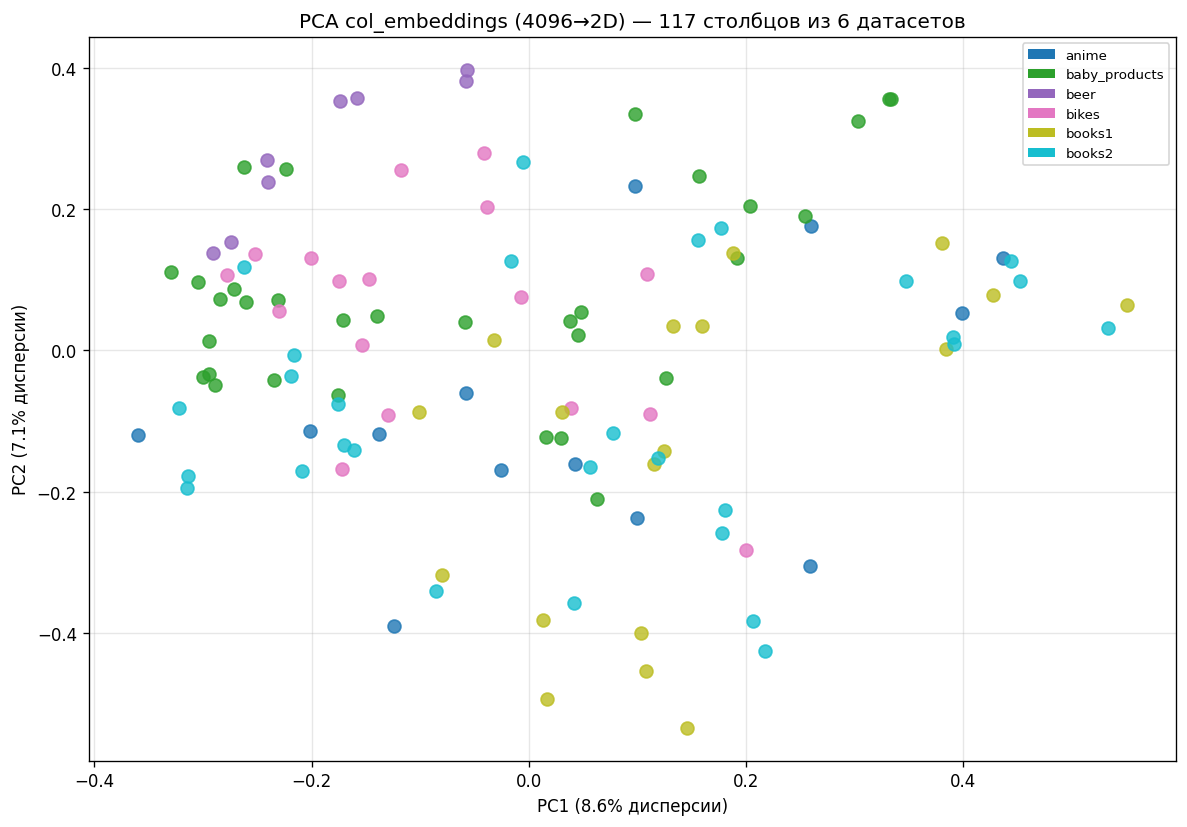

Объяснённая дисперсия PC1+PC2: 15.7%


In [16]:
from sklearn.decomposition import PCA

# Собираем col_embeddings из нескольких датасетов
SAMPLE_DS = [s["name"] for s in all_stats[:6]]  # первые 6 датасетов
all_col_embs, all_col_labels, all_col_ds = [], [], []

for ds_name in SAMPLE_DS:
    g_path = GRAPHS_DIR / ds_name / "graph.pt"
    if not g_path.exists():
        continue
    g = torch.load(g_path, weights_only=False)
    embs = g.col_embeddings.numpy()  # [n_cols, 4096]
    for i, emb in enumerate(embs):
        all_col_embs.append(emb)
        all_col_labels.append(f"{ds_name}:col_{i}")
        all_col_ds.append(ds_name)

col_matrix = np.stack(all_col_embs)  # [total_cols, 4096]

# PCA → 2D
pca = PCA(n_components=2, random_state=42)
col_2d = pca.fit_transform(col_matrix)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(SAMPLE_DS)))
ds_to_color = dict(zip(SAMPLE_DS, colors))

for i, (x, y) in enumerate(col_2d):
    ds = all_col_ds[i]
    ax.scatter(x, y, color=ds_to_color[ds], s=60, alpha=0.8, zorder=3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=ds_to_color[ds], label=ds) for ds in SAMPLE_DS]
ax.legend(handles=legend_elements, fontsize=8, loc="best")
ax.set_title(f"PCA col_embeddings (4096→2D) — {len(all_col_embs)} столбцов из {len(SAMPLE_DS)} датасетов")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Объяснённая дисперсия PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")